In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Loading the dataset

In [62]:
data = pd.read_csv(r"C:\Users\New\Desktop\Jupyter Notebook\Data Science Project\Uber_Data.csv")

In [63]:
# copying data to another variable to avoid any changes to original data
df = data.copy()

### Data Overview

In [64]:
df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,01-01-2015 01:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,01-01-2015 01:00,Brooklyn,1519,5.0,10.0,NaN,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,01-01-2015 01:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,01-01-2015 01:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,01-01-2015 01:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


In [65]:
df.tail()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
29096,30-06-2015 23:00,EWR,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29097,30-06-2015 23:00,Manhattan,3828,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29098,30-06-2015 23:00,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29099,30-06-2015 23:00,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29100,30-06-2015 23:00,NaN,3,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N


In [66]:
#Checking the shape of the data
df.shape

(29101, 13)

- *The dataset has 29,101 rows and 13 columns*

In [67]:
#Checking the data types of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pickup_dt  29101 non-null  str    
 1   borough    26058 non-null  str    
 2   pickups    29101 non-null  int64  
 3   spd        29101 non-null  float64
 4   vsb        29101 non-null  float64
 5   temp       28742 non-null  float64
 6   dewp       29101 non-null  float64
 7   slp        29101 non-null  float64
 8   pcp01      29101 non-null  float64
 9   pcp06      29101 non-null  float64
 10  pcp24      29101 non-null  float64
 11  sd         29101 non-null  float64
 12  hday       29101 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 2.9 MB


- *All the columns have 29,101 observations except `borough` and `temp` which has 26058 and 28742 observations indicating that there are some missing values in them*
- *The `pickup_dt` column is being read as a 'object' data type but it should be in date-time format*
- *The `borough` and `hday` columns are of object type while the rest of the columns are numerical in nature*
- *The object type columns contain categories in them*

#### **Getting the statistical summary for the dataset**

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickups,29101.0,490.215903,995.649536,0.0,1.0,54.0,449.000000,7883.00
spd,29101.0,5.984924,3.699007,0.0,3.0,6.0,8.000000,21.00
vsb,29101.0,8.818125,2.442897,0.0,9.1,10.0,10.000000,10.00
temp,28742.0,47.900019,19.798783,2.0,32.0,46.5,65.000000,89.00
dewp,29101.0,30.823065,21.283444,-16.0,14.0,30.0,50.000000,73.00
slp,29101.0,1017.817938,7.768796,991.4,1012.5,1018.2,1022.900000,1043.40
pcp01,29101.0,0.003830,0.018933,0.0,0.0,0.0,0.000000,0.28
pcp06,29101.0,0.026129,0.093125,0.0,0.0,0.0,0.000000,1.24
pcp24,29101.0,0.090464,0.219402,0.0,0.0,0.0,0.050000,2.10
sd,29101.0,2.529169,4.520325,0.0,0.0,0.0,2.958333,19.00


- *There is a huge difference between the 3rd quartile and the maximum value for the number of pickups (`pickups`) and snow depth (`sd`) indicating that there might be outliers to the right in these variables*
- *The temperature has a wide range indicating that data consists of entries for different seasons*

In [69]:
#Checking for the number of unique values in each column
df['borough'].unique()

<StringArray>
['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', nan]
Length: 7, dtype: str

- *We observe that there are 6 unique boroughs present in the dataset for New York*

In [70]:
df['hday'].value_counts(normalize=True)

hday
N    0.961479
Y    0.038521
Name: proportion, dtype: float64

- *The number of non-holiday observations is much more than holiday observations which make sense*
-*Around 96% of the observations are from non-holidays*


In [71]:
#Changing the data type of pickup_dt column to datetime format
df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], format="%d-%m-%Y %H:%M")

In [72]:
# Rechecking the data types of the columns after changing the data type of pickup_dt column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   pickup_dt  29101 non-null  datetime64[us]
 1   borough    26058 non-null  str           
 2   pickups    29101 non-null  int64         
 3   spd        29101 non-null  float64       
 4   vsb        29101 non-null  float64       
 5   temp       28742 non-null  float64       
 6   dewp       29101 non-null  float64       
 7   slp        29101 non-null  float64       
 8   pcp01      29101 non-null  float64       
 9   pcp06      29101 non-null  float64       
 10  pcp24      29101 non-null  float64       
 11  sd         29101 non-null  float64       
 12  hday       29101 non-null  str           
dtypes: datetime64[us](1), float64(9), int64(1), str(2)
memory usage: 2.9 MB


In [73]:
df['pickup_dt'].min() # this will display the date from which data observations have been started

Timestamp('2015-01-01 01:00:00')

In [74]:
df['pickup_dt'].max() # this will display the last date of the dataset

Timestamp('2015-06-30 23:00:00')

- *So the time period for the data is from Janunary to June for the year 2015*
- *There is a significant difference in the weather conditions in this period which we have observed from our statistical summary for various weather parameters such as temperature ranging from 2F to 89F*

In [75]:
# Extracting date parts from pickup date
df['start_year'] = df.pickup_dt.dt.year # extracting the year from the date
df['start_month'] = df.pickup_dt.dt.month_name() # extracting the month name from the date
df['start_hour'] = df.pickup_dt.dt.hour # extracting the hour from the time
df['start_day'] = df.pickup_dt.dt.day # extracting the day from the date
df['week_day'] = df.pickup_dt.dt.day_name() # extracting the day of the week from the date

In [76]:
# removing the pickup date column
df.drop('pickup_dt',axis=1,inplace=True) 

In [77]:
#Checking the data after extracting the date parts from pickup date
df.head()

,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday,start_year,start_month,start_hour,start_day,week_day
0,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
1,Brooklyn,1519,5.0,10.0,NaN,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
2,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
3,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday
4,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,2015,January,1,1,Thursday


In [18]:
df.describe(include='all').T
# setting include='all' will get the statistical summary for both the numerical and categorical variables.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
borough,26058,6,Bronx,4343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickups,29101.0,NaN,NaN,NaN,490.215903,995.649536,0.0,1.0,54.0,449.0,7883.0
spd,29101.0,NaN,NaN,NaN,5.984924,3.699007,0.0,3.0,6.0,8.0,21.0
vsb,29101.0,NaN,NaN,NaN,8.818125,2.442897,0.0,9.1,10.0,10.0,10.0
temp,28742.0,NaN,NaN,NaN,47.900019,19.798783,2.0,32.0,46.5,65.0,89.0
dewp,29101.0,NaN,NaN,NaN,30.823065,21.283444,-16.0,14.0,30.0,50.0,73.0
slp,29101.0,NaN,NaN,NaN,1017.817938,7.768796,991.4,1012.5,1018.2,1022.9,1043.4
pcp01,29101.0,NaN,NaN,NaN,0.00383,0.018933,0.0,0.0,0.0,0.0,0.28
pcp06,29101.0,NaN,NaN,NaN,0.026129,0.093125,0.0,0.0,0.0,0.0,1.24
pcp24,29101.0,NaN,NaN,NaN,0.090464,0.219402,0.0,0.0,0.0,0.05,2.1


- *The collected data is from the year 2015*
- *It consists of data for 6 unique months*

In [78]:
# checking missing values across each columns
df.isnull().sum()

borough        3043
pickups           0
spd               0
vsb               0
temp            359
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
start_year        0
start_month       0
start_hour        0
start_day         0
week_day          0
dtype: int64

- *The variable `borough` and `temp ` have 3043 and 359 missing values in them*
- *There are no missing values in other variables*

In [79]:
# Checking the missing values further
df.borough.value_counts(normalize=True, dropna=False)

borough
Bronx            0.149239
Brooklyn         0.149239
EWR              0.149239
Manhattan        0.149239
Queens           0.149239
Staten Island    0.149239
NaN              0.104567
Name: proportion, dtype: float64

- *All the 6 categories have the same percentage i.e. ~15%. There is no mode (or multiple modes) for this variable*
- *The percentage of missing values is close to the percentage of observations from other boroughs*
- *We can treat the missing values as a separate category for this variable*

In [122]:
# Replacing NaN with Unknown
df['borough'].fillna('unknown', inplace =True)

C:\Users\New\AppData\Local\Temp\ipykernel_9336\1452496847.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['borough'].fillna('unknown', inplace =True)


0                Bronx
1             Brooklyn
2                  EWR
3            Manhattan
4               Queens
             ...      
29096              EWR
29097        Manhattan
29098           Queens
29099    Staten Island
29100          unknown
Name: borough, Length: 29101, dtype: str

In [123]:
df['borough'].unique()

<StringArray>
['Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island', nan]
Length: 7, dtype: str

In [118]:
df.isnull().sum()

borough        3043
pickups           0
spd               0
vsb               0
temp              0
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
start_year        0
start_month       0
start_hour        0
start_day         0
week_day          0
dtype: int64

In [120]:
# Checking the missing values further
df.loc[df['temp'].isnull()==True]

,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday,start_year,start_month,start_hour,start_day,week_day


*There are 359 observations where `temp` variable has missing values. From the overview of the dataset, it seems as if the missing temperature values are from the Brooklyn borough in the month of January.*

confirming the hypothesis by printing the unique boroughs and month names present for these missing values.

In [110]:
df.loc[df['temp'].isnull()==True,'borough'].value_counts()

Series([], Name: count, dtype: int64)

In [111]:
df.loc[df['temp'].isnull()==True,'start_month'].value_counts()

Series([], Name: count, dtype: int64)

*The missing values in `temp` are from the Brooklyn borough and they are from the month of January.*

Let's check on which the date for the month of  January, missing values are present.

In [112]:
df.loc[df['temp'].isnull()==True,'start_day'].unique() # days for which missing values are present

array([], dtype=int32)

In [113]:
df.loc[df['start_month']=='January', 'start_day'].unique() # unique days in the month of January

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype=int32)

*It can be observed  that out of the 31 days in January, the data is missing for the first 15 days.*

In [114]:
#Creating a new column to check the missing values in temp column for the month of January and days greater than 15
df['temp'] = df['temp'].fillna(value=df.loc[(df['borough'] == 'Brooklyn') & (df['start_month'] == 'January') & (df['start_day'] >= 16),'temp'].mean())

In [115]:
df.isnull().sum()

borough        3043
pickups           0
spd               0
vsb               0
temp              0
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
start_year        0
start_month       0
start_hour        0
start_day         0
week_day          0
dtype: int64

In [31]:
#Creating a new column to check the missing values in temp column for the month of January and days greater than 15
df['borough'] = df['temp'].fillna(value=df.loc[(df['borough'] == 'Brooklyn') & (df['start_month'] == 'January') & (df['start_day'] >= 16),'temp'].mean())

In [104]:
df.isnull().sum()

borough        3043
pickups           0
spd               0
vsb               0
temp              0
dewp              0
slp               0
pcp01             0
pcp06             0
pcp24             0
sd                0
hday              0
start_year        0
start_month       0
start_hour        0
start_day         0
week_day          0
dtype: int64

- *All the missing values have been imputed and there are no missing values in our dataset now*.

### **Exploratory Data Analysis**

### **Univariate Analysis**

**Observations on Pickups**

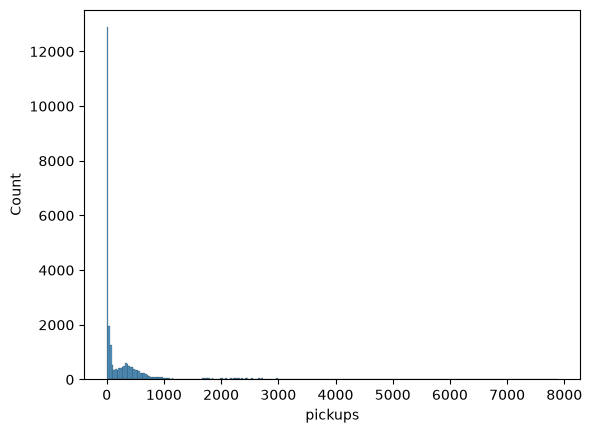

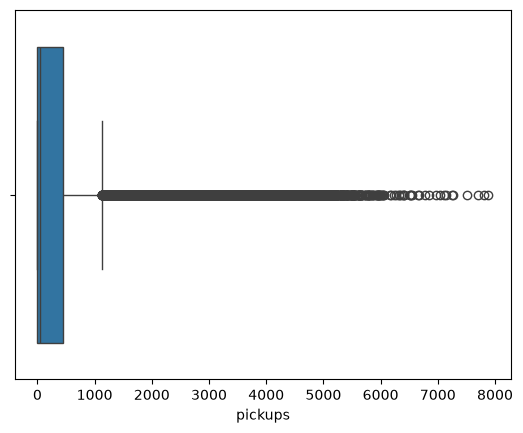

In [124]:
sns.histplot(data=df,x='pickups')
plt.show()
sns.boxplot(data=df,x='pickups')
plt.show()

- *The distribution of pickups is highly right skewed*
- *There are a lot of outliers in this variable*
- *While mostly the number of pickups are at a lower end, we have observations where the number of pickups went as high as 8000*

**Observations on Visibility**

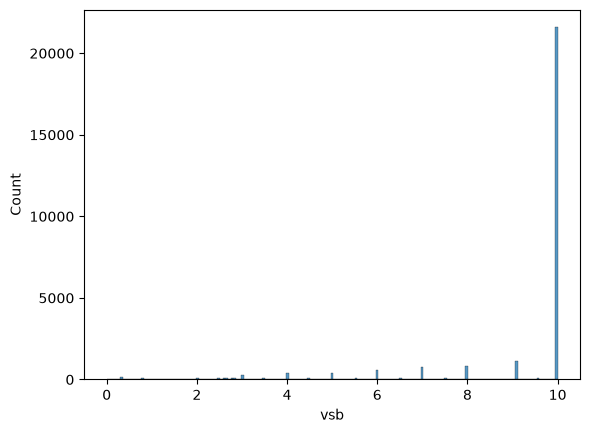

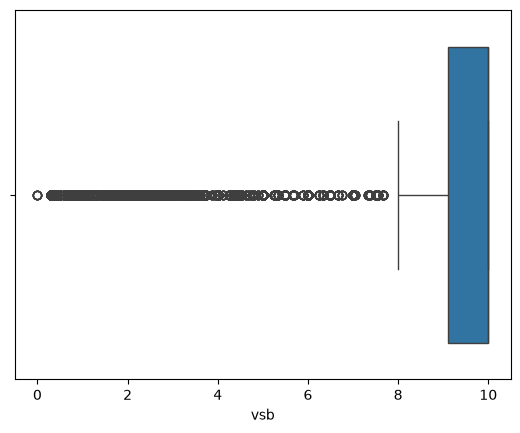

In [34]:
sns.histplot(data=df,x='vsb')
plt.show()
sns.boxplot(data=df,x='vsb')
plt.show()

- *The `visibility` column is is left-skewed*
- *Both the mean and median are high, indicating that the visibility is good on most days*
- *There are, however, outliers towards the left, indicating that visibility is extremely low on some days*
- *It will be interesting to see how visibility affects the Uber pickup frequency*

**Observations on Temperature**

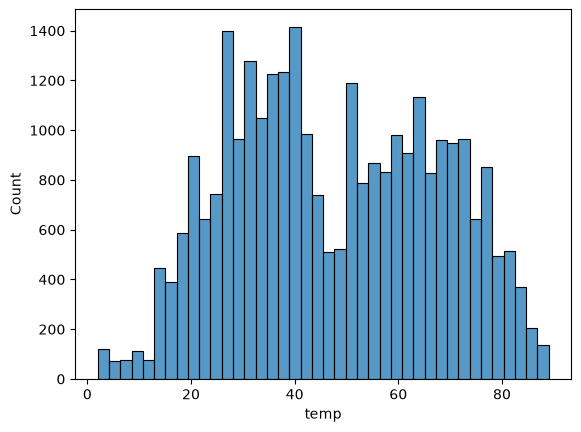

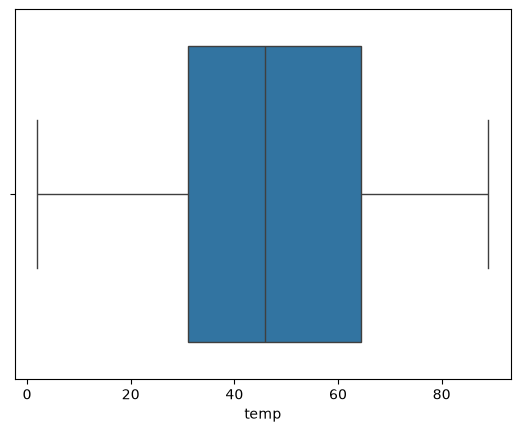

In [35]:
sns.histplot(data=df,x='temp')
plt.show()
sns.boxplot(data=df,x='temp')
plt.show()

- *Temperature does not have any outliers*
- *50% of the temperature values are less than 45F (~7 degree celcius), indicating cold weather conditions*

**Observations on Dew point**

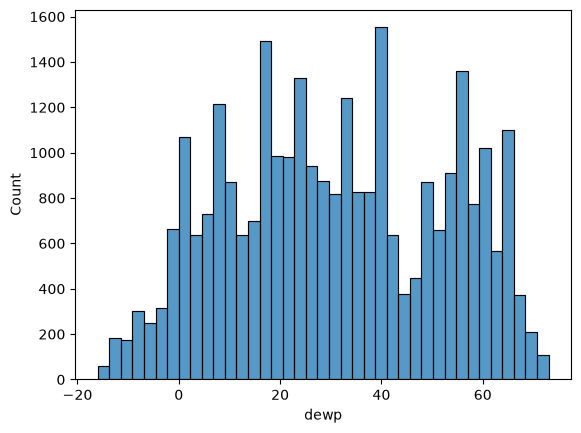

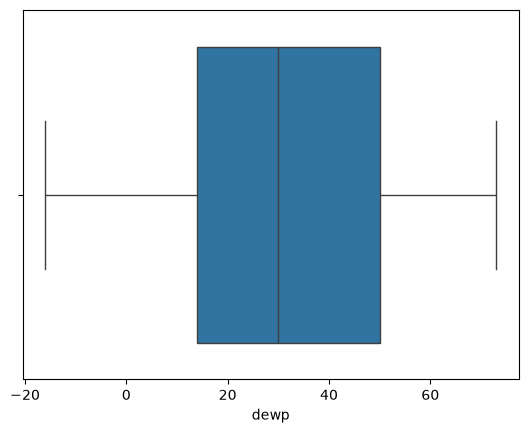

In [36]:
sns.histplot(data=df,x='dewp')
plt.show()
sns.boxplot(data=df,x='dewp')
plt.show()

- *There are no outliers for dew point either*
- *The distribution is similar to that of temperature. It suggests possible correlation between the two variables*
- *Dew point is an indication of humidity, which is correlated with temperature*

**Observations on Sea level pressure**

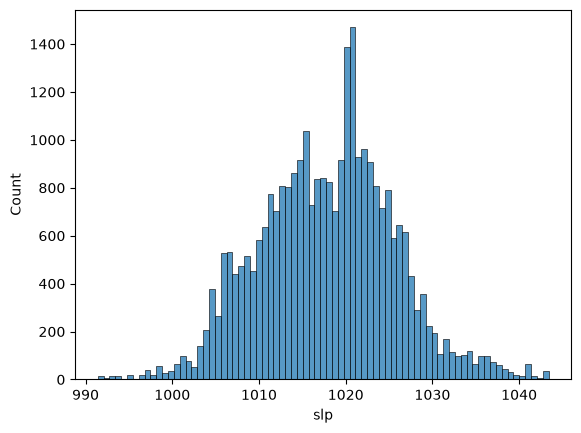

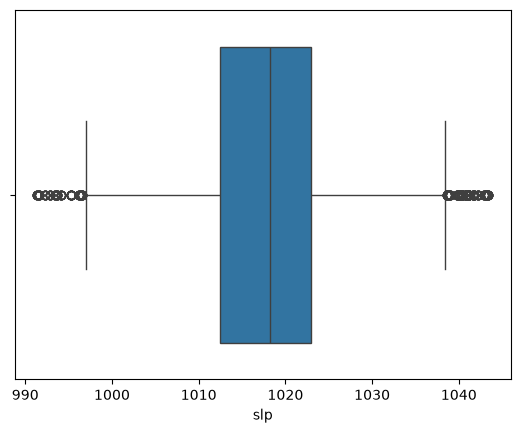

In [37]:
sns.histplot(data=df,x='slp')
plt.show()
sns.boxplot(data=df,x='slp')
plt.show()

- *Sea level pressure distribution is close to normal*
- *There are a few outliers on both the ends*

**Observations on Liquid Precipitation (Rain)**

**1 hour liquid precipitation**

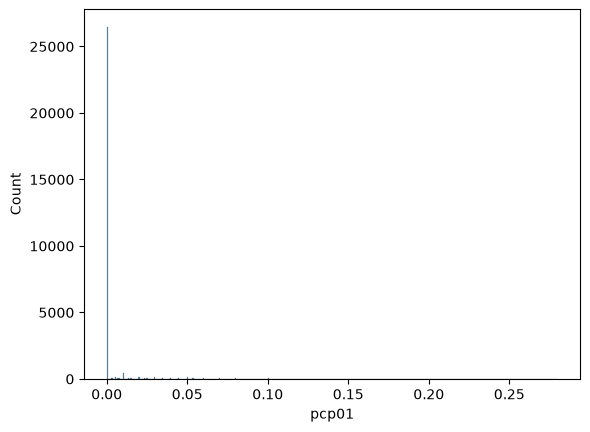

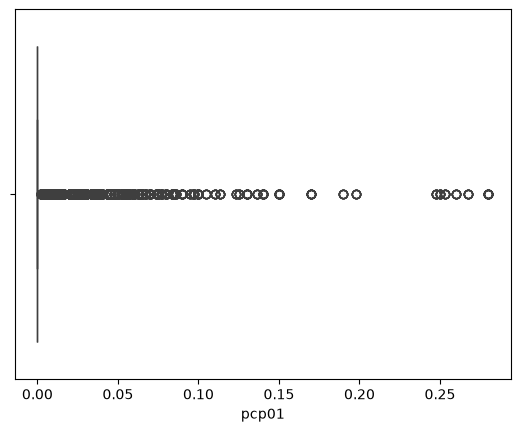

In [38]:
sns.histplot(data=df,x='pcp01')
plt.show()
sns.boxplot(data=df,x='pcp01')
plt.show()

**6 hour liquid precipitation**

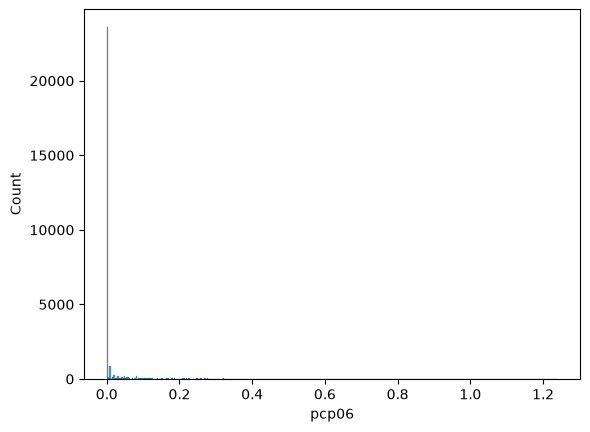

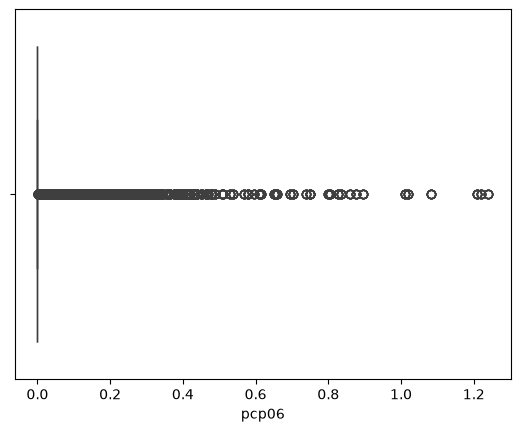

In [39]:
sns.histplot(data=df,x='pcp06')
plt.show()
sns.boxplot(data=df,x='pcp06')
plt.show()

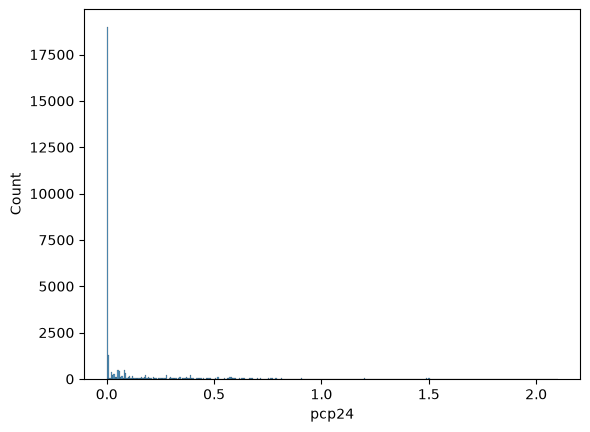

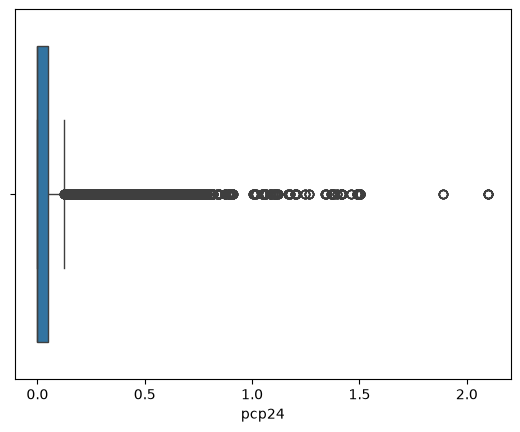

In [40]:
sns.histplot(data=df,x='pcp24')
plt.show()
sns.boxplot(data=df,x='pcp24')
plt.show()

- *It rains on relatively fewer days in New York*
- *Most of the days are dry*
- *The outliers occur when it rains heavily*

**Observations on Snow Depth**

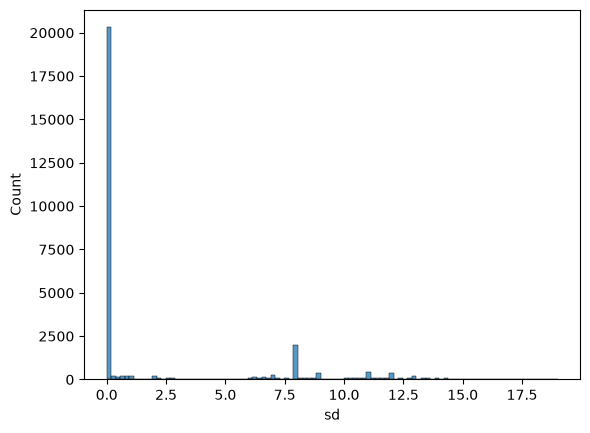

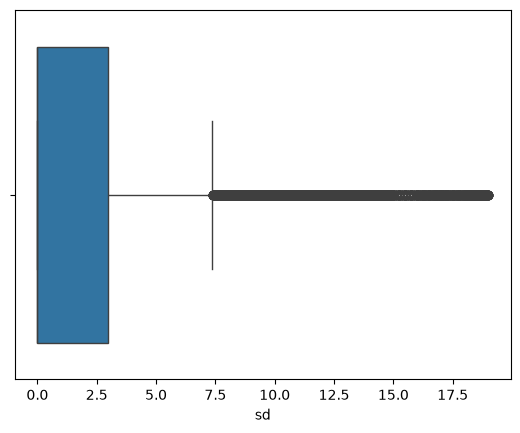

In [41]:
sns.histplot(data=df,x='sd')
plt.show()
sns.boxplot(data=df,x='sd')
plt.show()

- *We can observe that there is snowfall in the time period that we are analyzing*
- *There are outliers in this data*

**Observations on holiday**

<Axes: xlabel='hday', ylabel='count'>

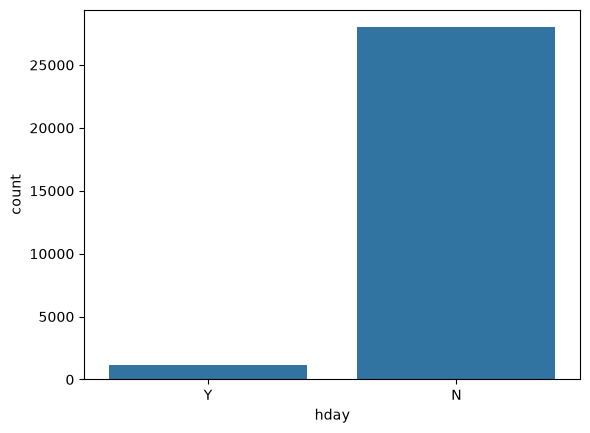

In [42]:
sns.countplot(data=df,x='hday')

- *The number of pickups is more on non-holidays than on holidays*

**Observations on borough**

### **Bivariate Analysis**

**Correlation by Heatmap**

In [43]:
# Selecting only the numerical columns
num_var = data.dtypes[data.dtypes != 'object'].index

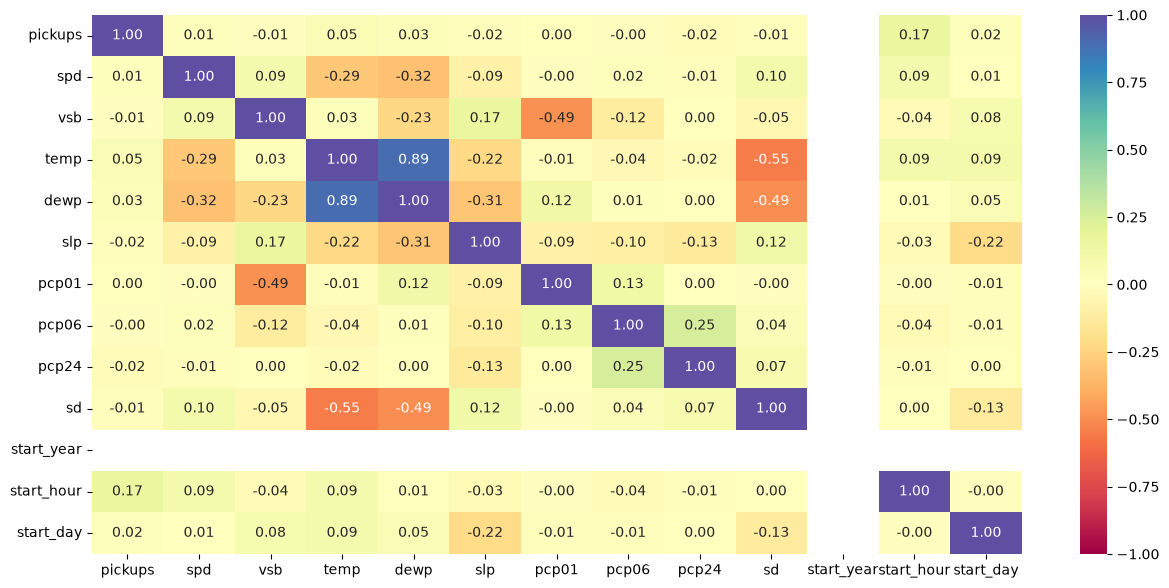

In [125]:
# Check for correlation among numerical variables

# Use only numeric columns that are actually present in df
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

# plot the heatmap

plt.figure(figsize=(15, 7))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- *As expected, temperature shows high correlation with dew point*
- *Visibility is negatively correlated with precipitation. If it is raining heavily, then the visibility will be low. This is aligned with our intuitive understanding*
* *Snow depth of course would be negatively correlated with temperature.*
* *Wind speed and sea level pressure are negatively correlated with temperature*
* *It is important to note that correlation does not imply causation*
* *There does not seem to be a strong relationship between number of pickups and weather stats*

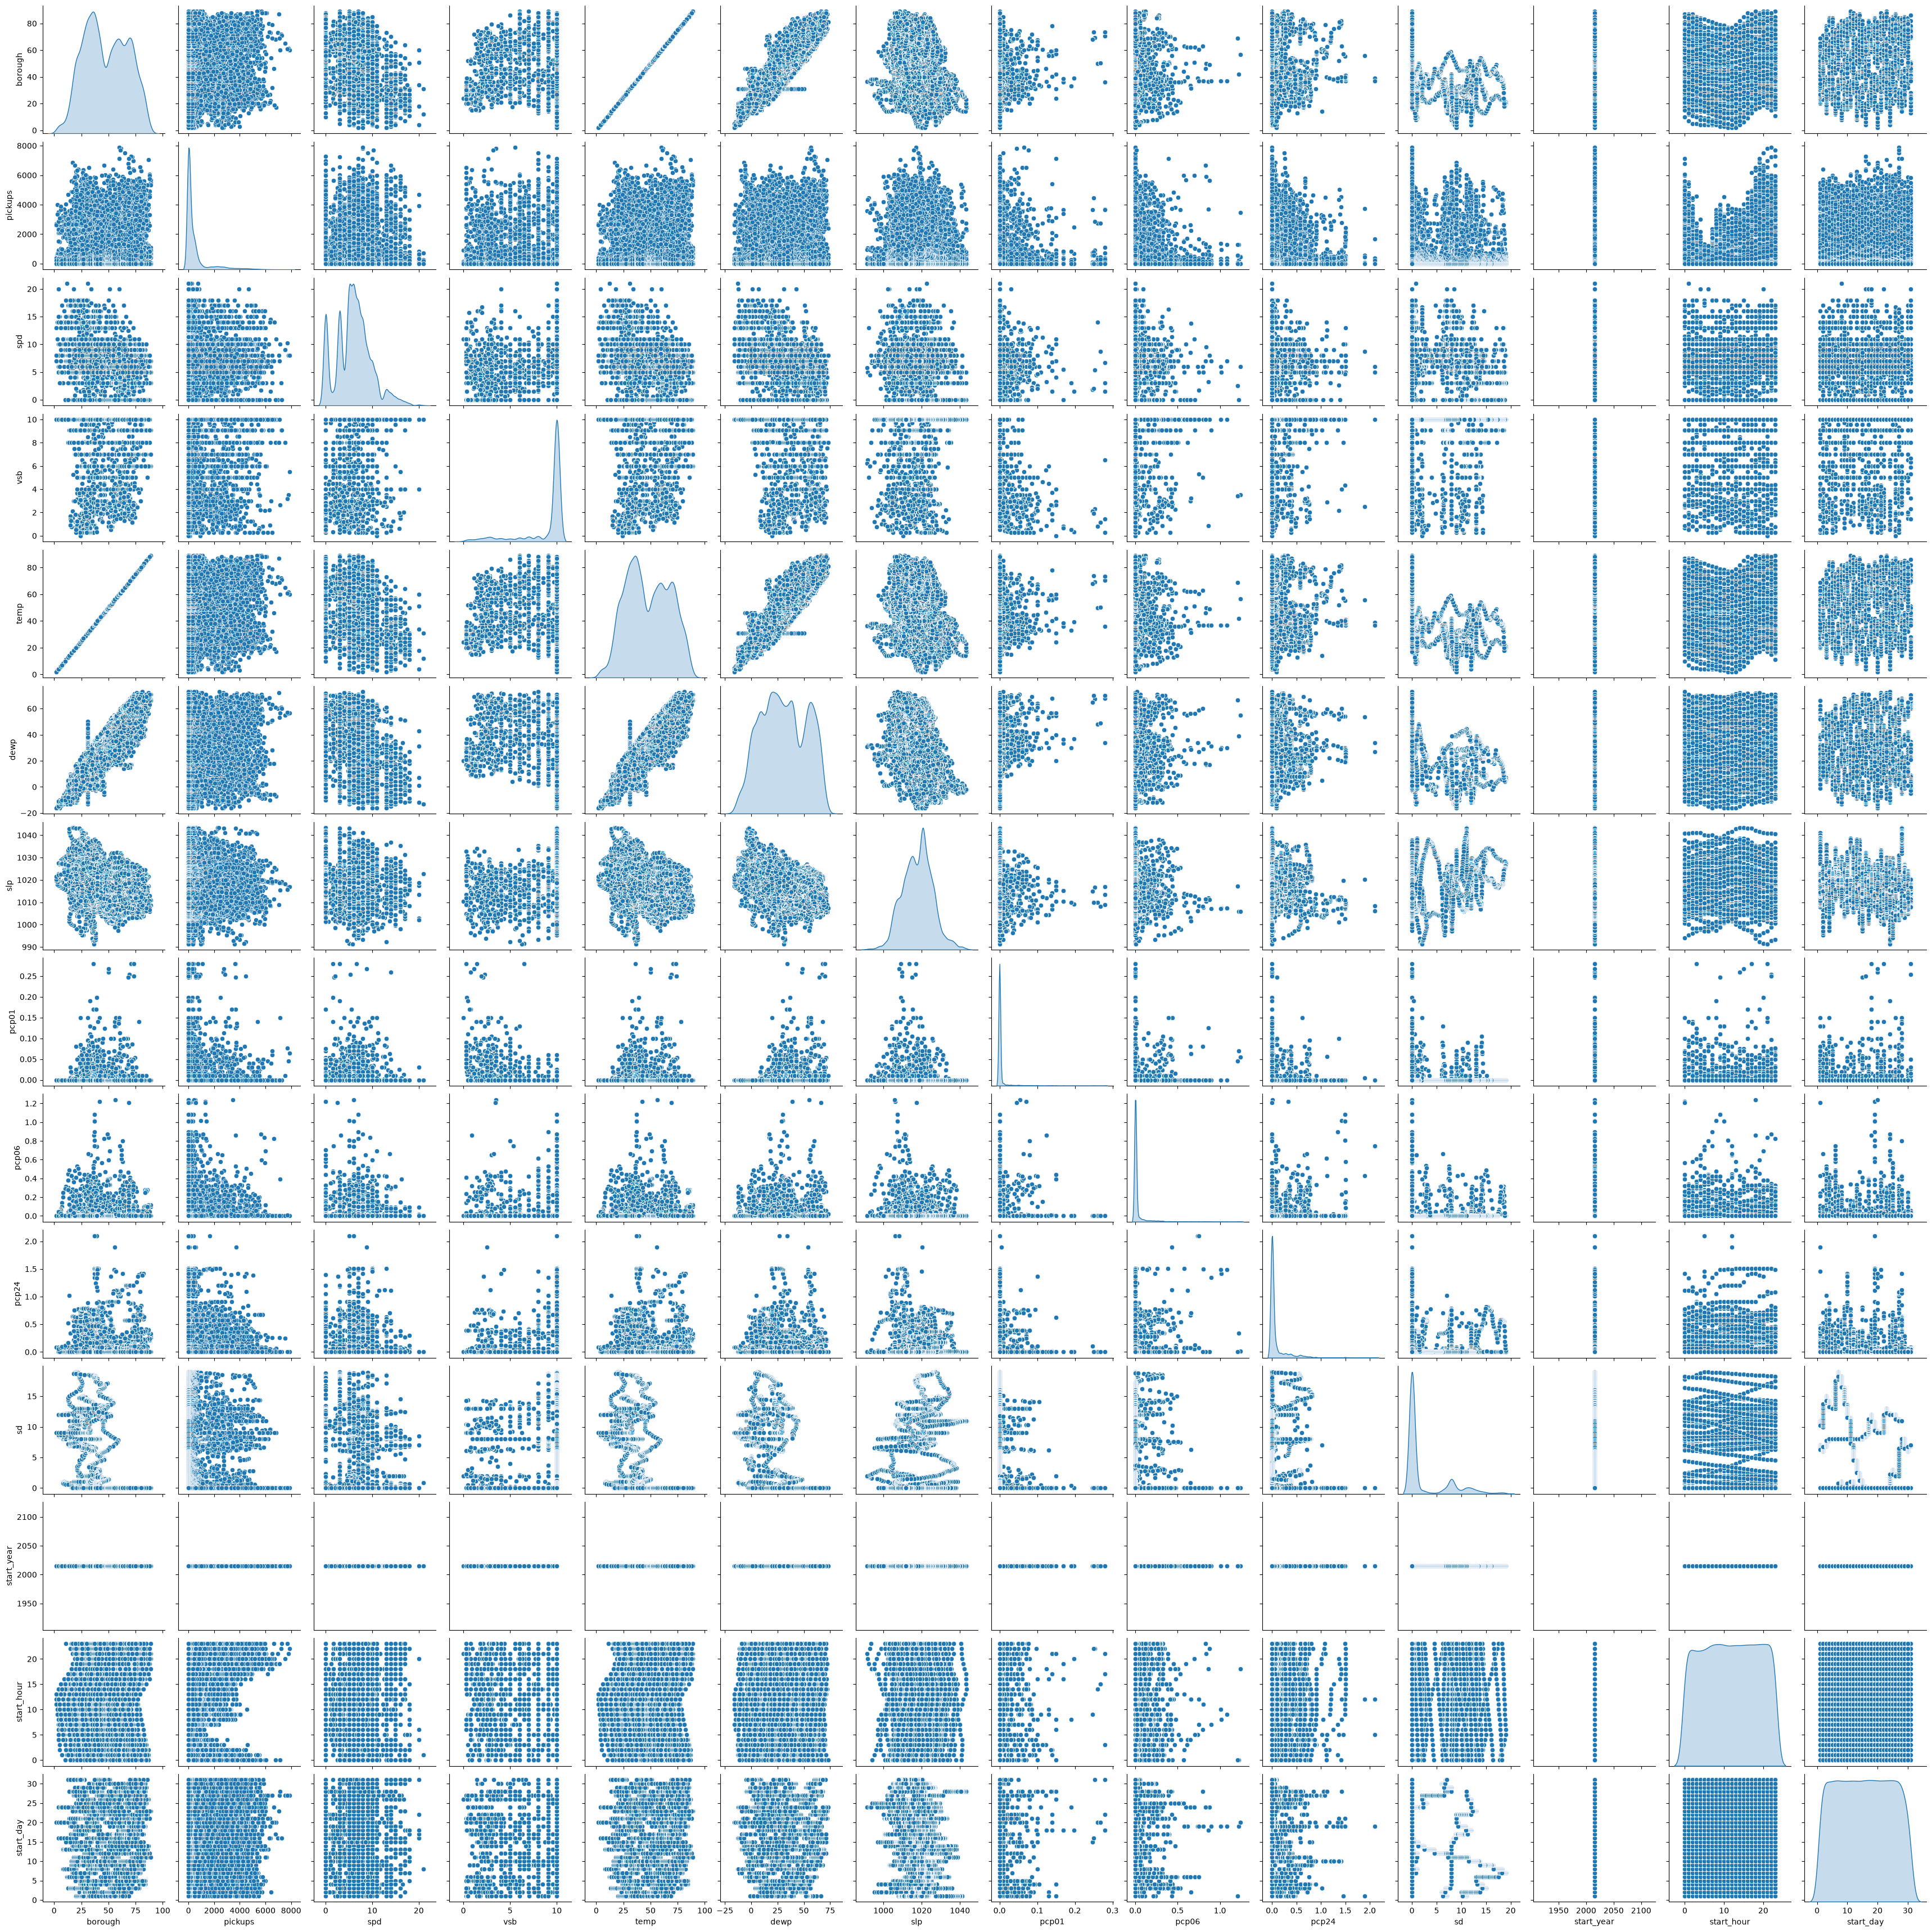

In [45]:
sns.pairplot(data=df[num_cols], diag_kind="kde")
plt.show()  

- *We get the same insights as from the correlation plot*
- *There does not seem to be a strong relationship between number of pickups and weather stats*

#### **Pickups across months**

C:\Users\New\AppData\Local\Temp\ipykernel_9336\3805454801.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="start_month", y="pickups", ci=False, color="red", estimator='sum')


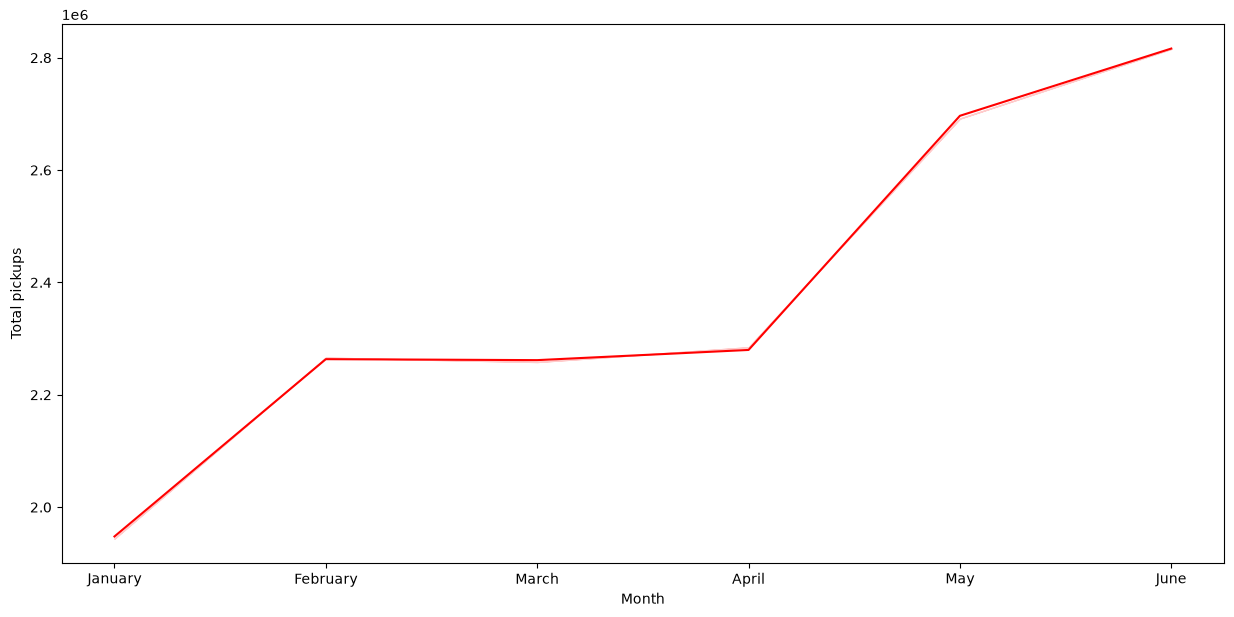

In [46]:
cats = df.start_month.unique().tolist()
df.start_month = pd.Categorical(df.start_month, ordered=True, categories=cats)

plt.figure(figsize=(15,7))
sns.lineplot(data=df, x="start_month", y="pickups", ci=False, color="red", estimator='sum')
plt.ylabel('Total pickups')
plt.xlabel('Month')
plt.show()

- *There is a clear increasing trend in monthly bookings*
- *The number of pickups in June is almost 2.8 times of that of January*

#### **Pickups vs Days of the Month**

C:\Users\New\AppData\Local\Temp\ipykernel_9336\2975266403.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="start_day", y="pickups", estimator='sum', ci=False, color="red")


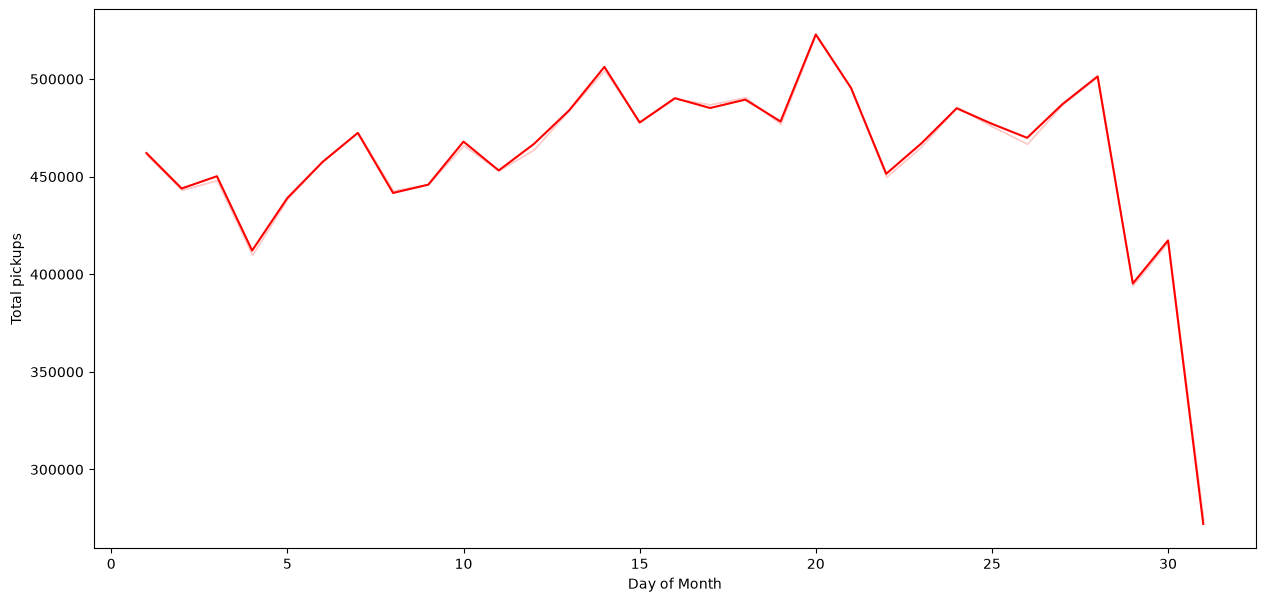

In [47]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x="start_day", y="pickups", estimator='sum', ci=False, color="red")
plt.ylabel('Total pickups')
plt.xlabel('Day of Month')
plt.show()

- *There is a steep fall in the number of pickups over the last days of the month*
- *This can partially be attributed to month of Feb having just 28 days. We can drop Feb and have a look at this chart again*
- *There is a peak in the bookings around the 20th day of the month*

C:\Users\New\AppData\Local\Temp\ipykernel_9336\4268475931.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df_not_feb, x="start_day", y="pickups", estimator='sum', ci=False, color="red")


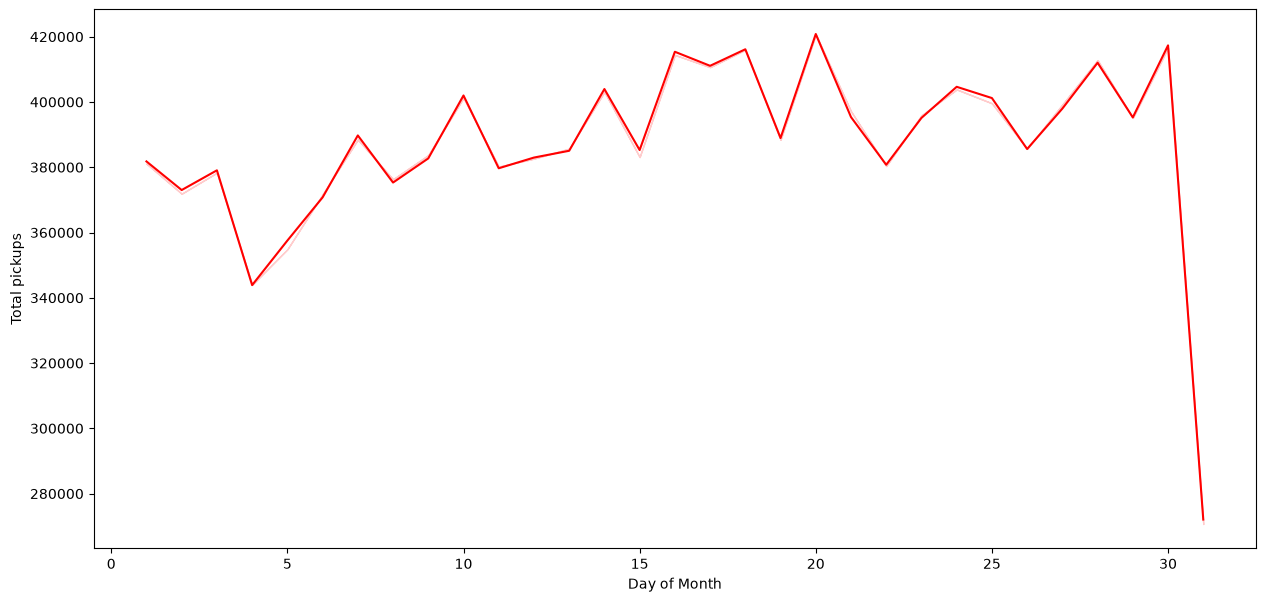

In [48]:
# Let us drop the Feb month and see the trend
df_not_feb =  df[df['start_month'] != 'February']
plt.figure(figsize=(15,7))
sns.lineplot(data=df_not_feb, x="start_day", y="pickups", estimator='sum', ci=False, color="red")
plt.ylabel('Total pickups')
plt.xlabel('Day of Month')
plt.show()

- *Number of pickups for 31st is still low because not all months have the 31st day*

**Pickups across Hours of the Day**

C:\Users\New\AppData\Local\Temp\ipykernel_9336\2066426633.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="start_hour", y="pickups", estimator='sum', ci=False, color="red")


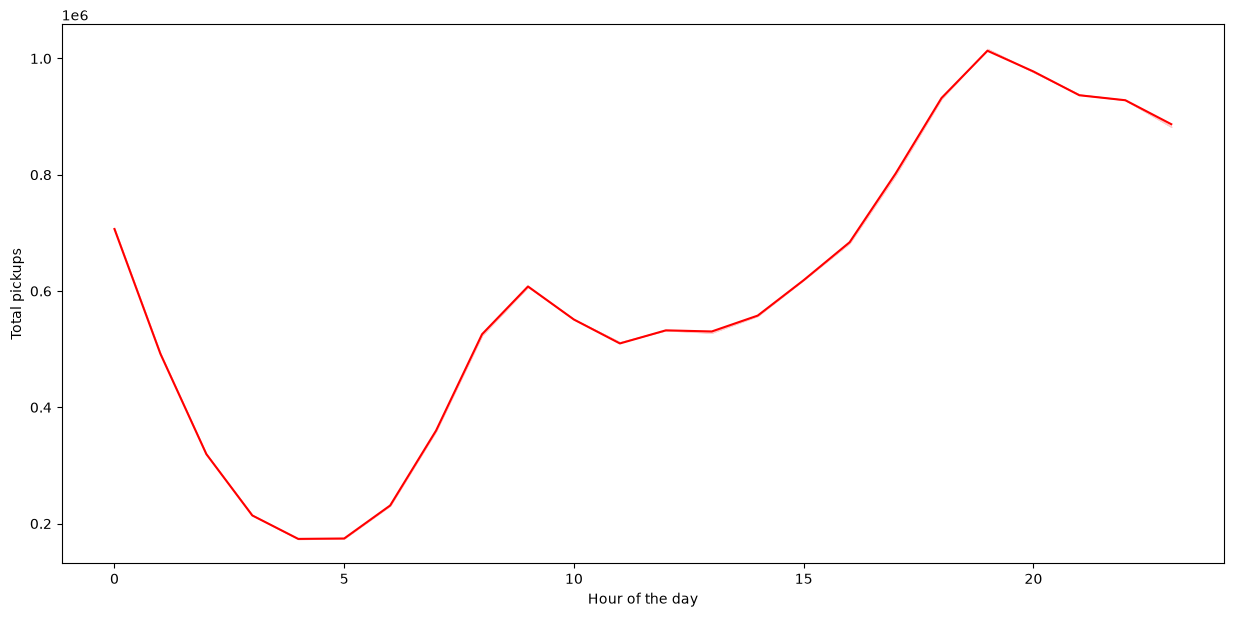

In [49]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x="start_hour", y="pickups", estimator='sum', ci=False, color="red")
plt.ylabel('Total pickups')
plt.xlabel('Hour of the day')
plt.show()

- *Bookings peak around the 19th and 20th hour of the day*
- *The peak can be attributed to the time when people leave their workplaces*
- *From 5 AM onwards, we can see an increasing trend till 10, possibly the office rush*
- *Pickups then go down from 10AM to 12PM post which they start increasing*

**Pickups across Weekdays**

C:\Users\New\AppData\Local\Temp\ipykernel_9336\2027432344.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="week_day", y="pickups", ci=False, color="red", estimator='sum')


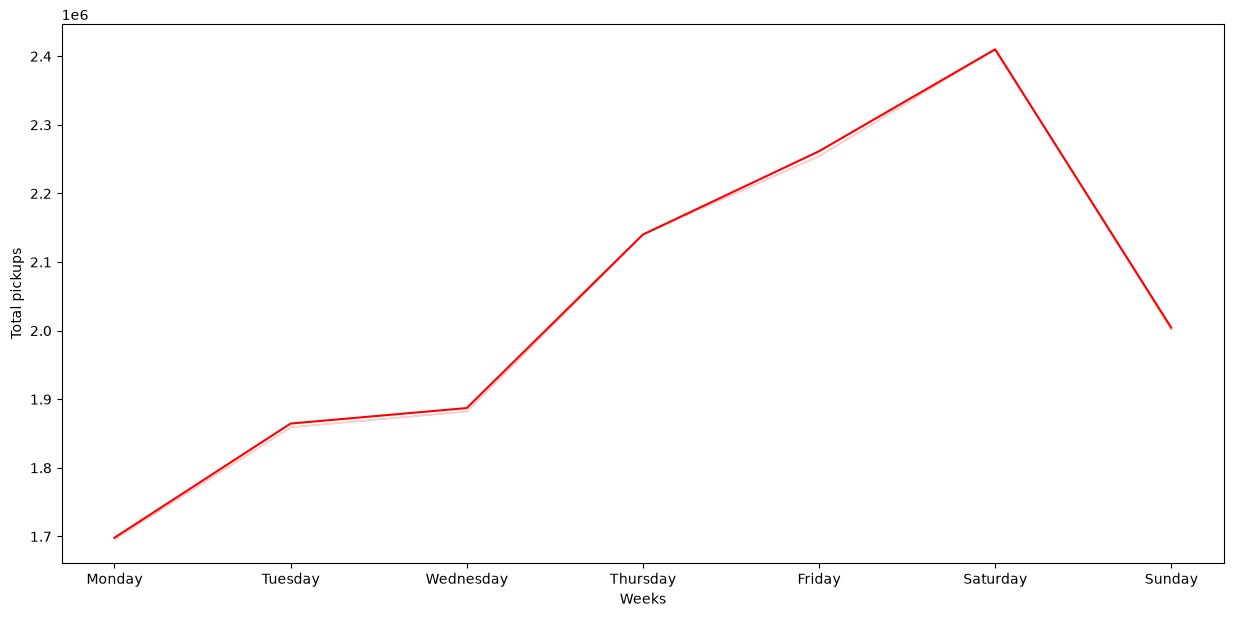

In [51]:
cats = ['Monday', 'Tuesday', 'Wednesday','Thursday', 'Friday', 'Saturday', 'Sunday']
df.week_day = pd.Categorical(df.week_day, ordered=True, categories=cats)

plt.figure(figsize=(15,7))
sns.lineplot(data=df, x="week_day", y="pickups", ci=False, color="red", estimator='sum')
plt.ylabel('Total pickups')
plt.xlabel('Weeks')
plt.show()

- *Pickups gradually increase as the week progresses and starts dropping down after Saturday*
- *We need to do more investigation to understand why demand for Uber is low in the beginning of the week*

**Pickups across Borough**

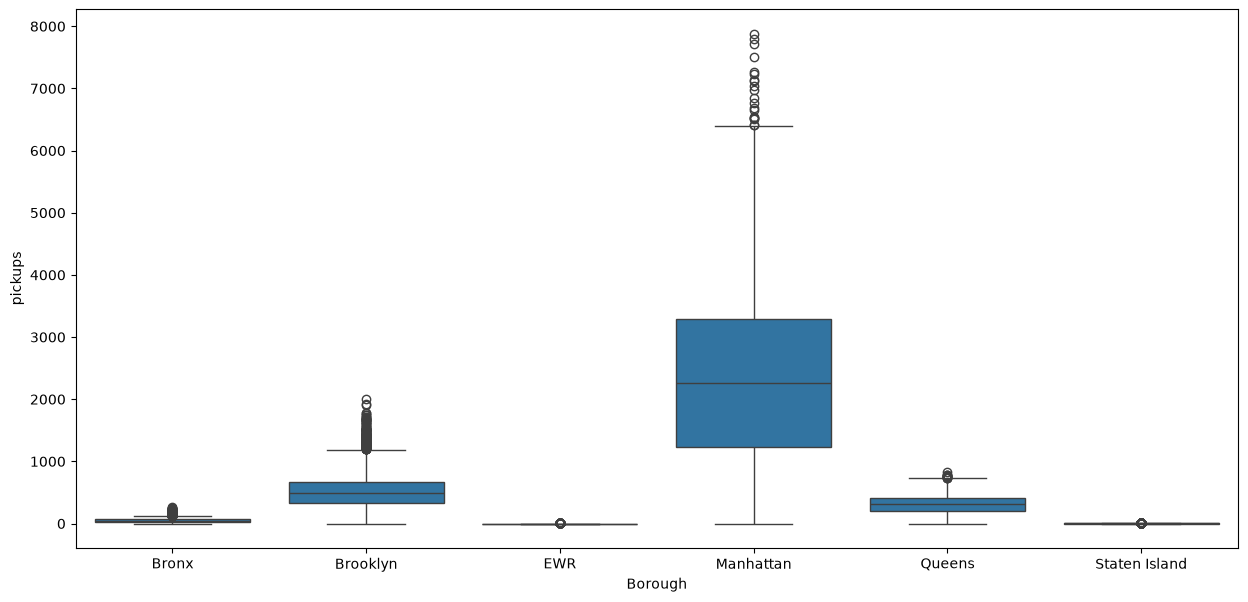

In [126]:
plt.figure(figsize=(15,7))
sns.boxplot(x=df['borough'], y=df['pickups'])
plt.ylabel('pickups')
plt.xlabel('Borough')
plt.show()

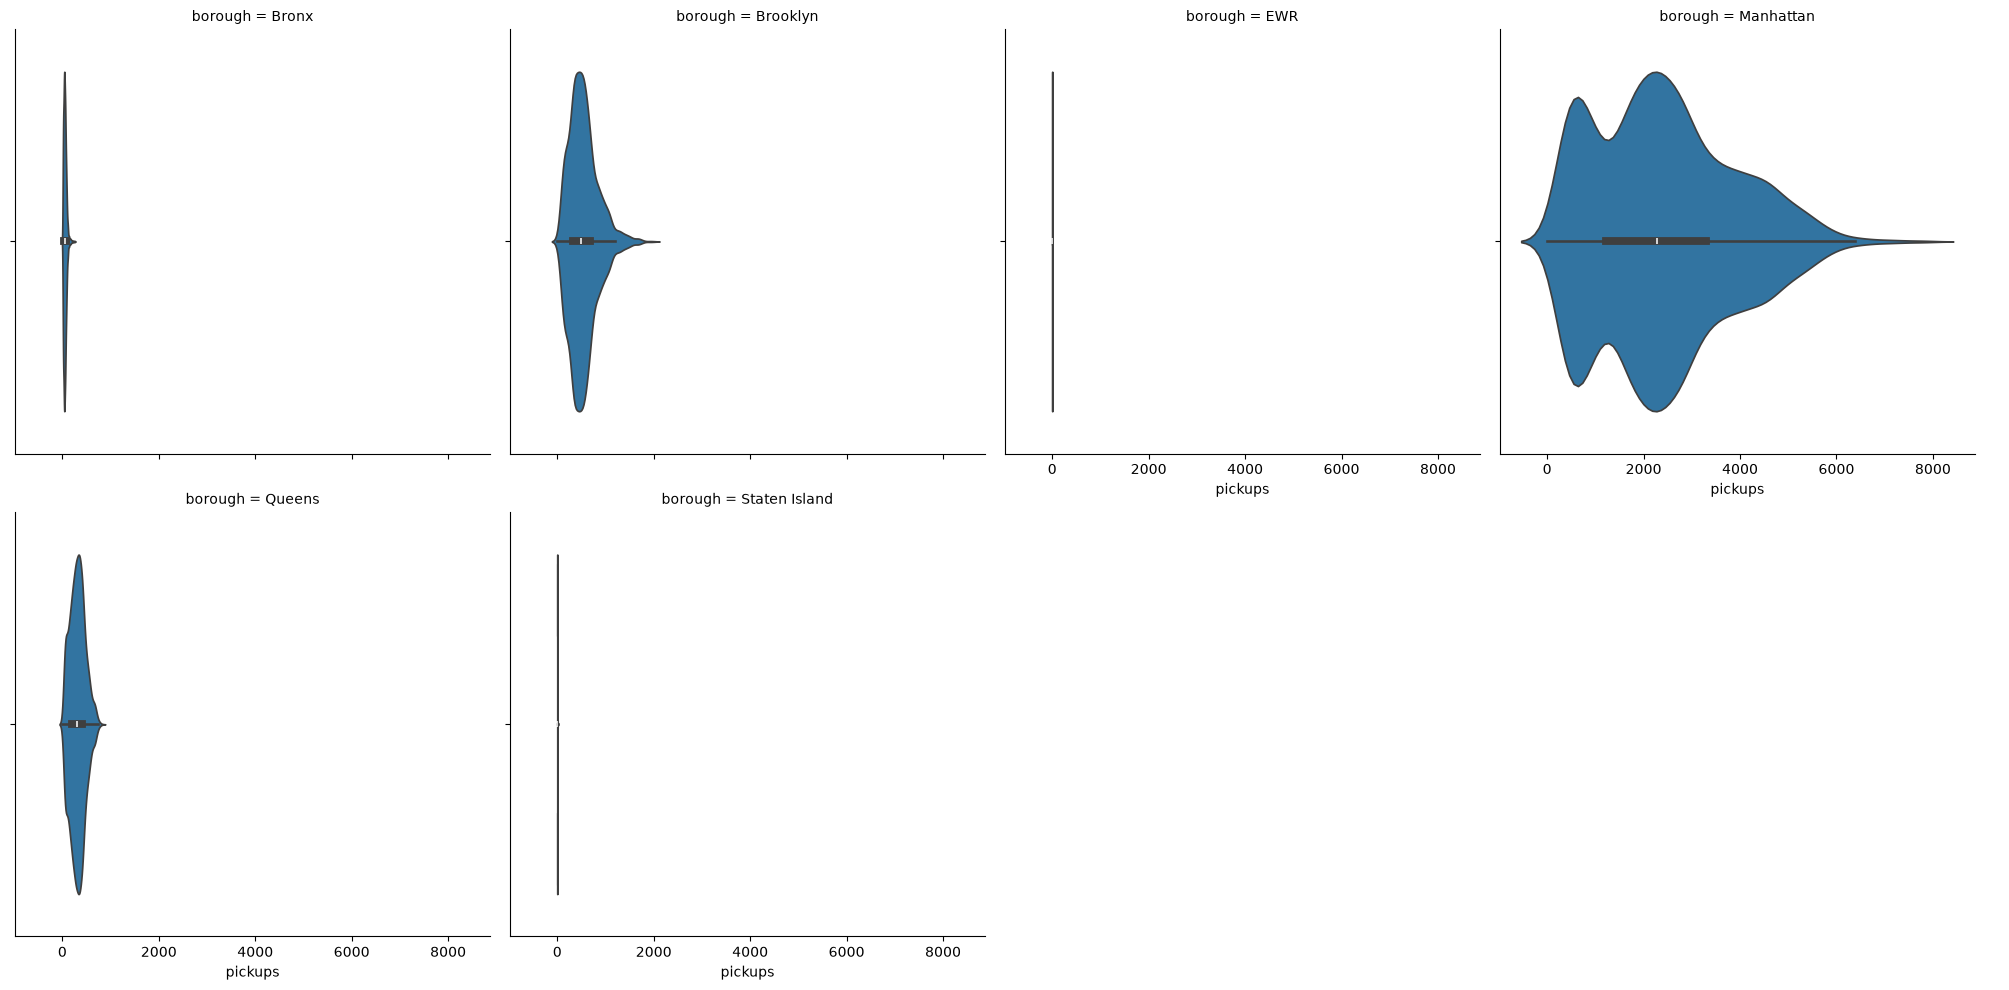

In [127]:
# Dispersion of pickups in every borough
sns.catplot(x='pickups', col='borough', data=df, col_wrap=4, kind="violin")
plt.show()

- *There is a clear difference in the number of riders across the different boroughs*
- *Manhattan has the highest number of bookings*
- *Brooklyn and Queens are distant followers*
- *EWR, Unknown and Staten Island have very low number of bookings. The demand is so small that probably it can be covered by the drop-offs of the inbound trips from other areas*

**Relationship between pickups and holidays**

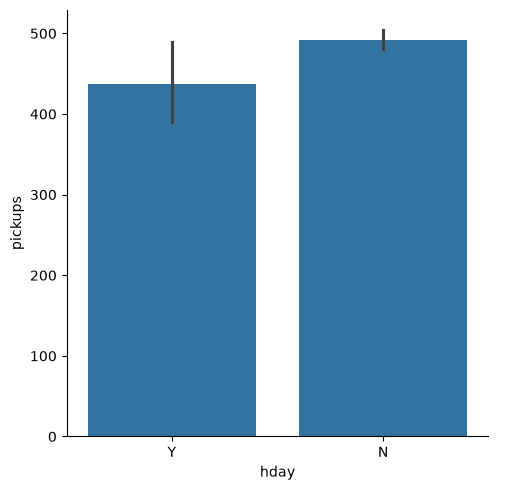

In [128]:
sns.catplot(x='hday', y='pickups', data=df, kind="bar")
plt.show()

- *The mean pickups on a holiday is lesser than that on a non-holiday*

### **Multivariate Analysis**

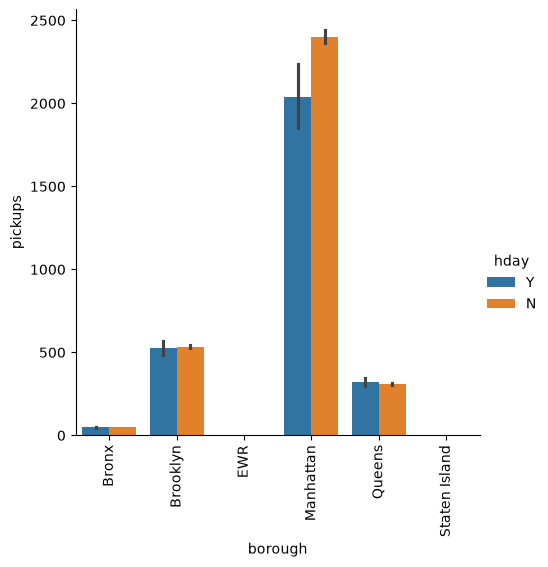

In [129]:
sns.catplot(x='borough', y='pickups', data=df, kind="bar", hue='hday')
plt.xticks(rotation=90)
plt.show()

The bars for EWR, Staten Island and Unknown are not visible. Let's check the mean pickups in all the borough to verify this.

In [130]:
# Check if the trend is similar across boroughs
df.groupby(by = ['borough','hday'])['pickups'].mean()

borough        hday
Bronx          N         50.771073
               Y         48.065868
Brooklyn       N        534.727969
               Y        527.011976
EWR            N          0.023467
               Y          0.041916
Manhattan      N       2401.302921
               Y       2035.928144
Queens         N        308.899904
               Y        320.730539
Staten Island  N          1.606082
               Y          1.497006
Name: pickups, dtype: float64

- *In all the boroughs, except Manhattan, the mean pickups on a holiday is very similar to that on a non holiday*
- *In Queens, mean pickups on a holiday is higher*
- *There are hardly any pickups in EWR*

Since we have seen that borough has a significant effect on the number of pickups, let's check if that effect is present across different hours of the day.

C:\Users\New\AppData\Local\Temp\ipykernel_9336\4265852655.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=df, x="start_hour", y="pickups", hue='borough', estimator='sum', ci=False)


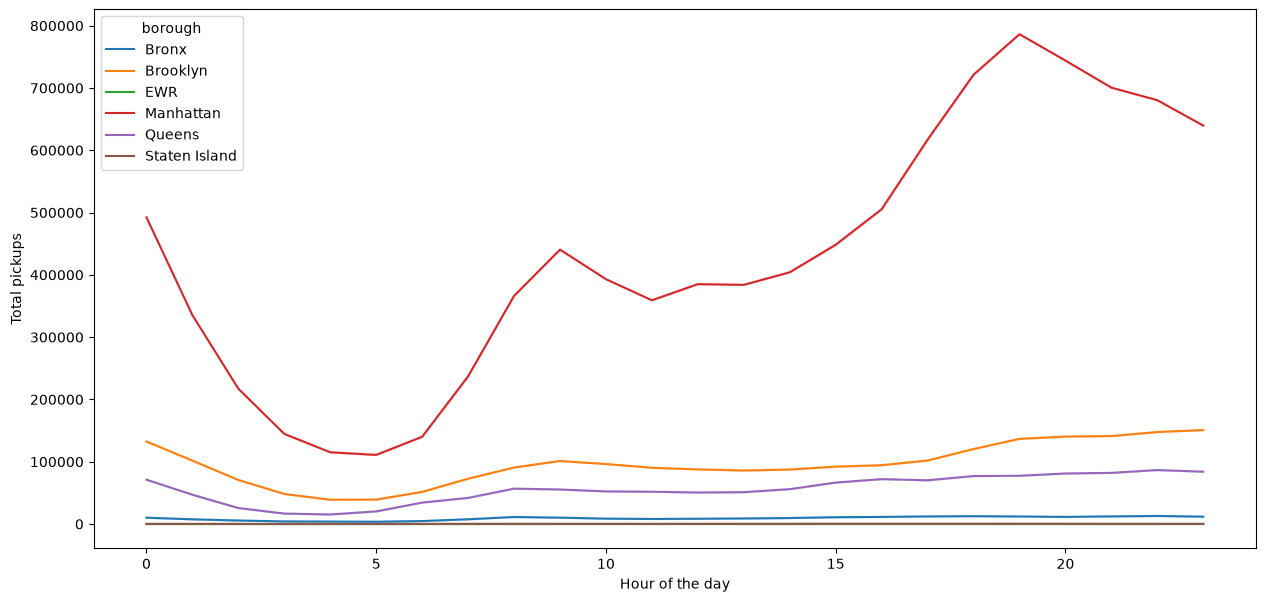

In [131]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x="start_hour", y="pickups", hue='borough', estimator='sum', ci=False)
plt.ylabel('Total pickups')
plt.xlabel('Hour of the day')
plt.show()

- *The number of pickups in Manhattan is very high and dominant when we see the spread across boroughs*
- *The hourly trend which we have observed earlier can be mainly attributed to the borough Manhattan, as rest of the other boroughs do not show any significant change for the number of pickups on the hourly basis*

### **Outlier Detection and Treatment**

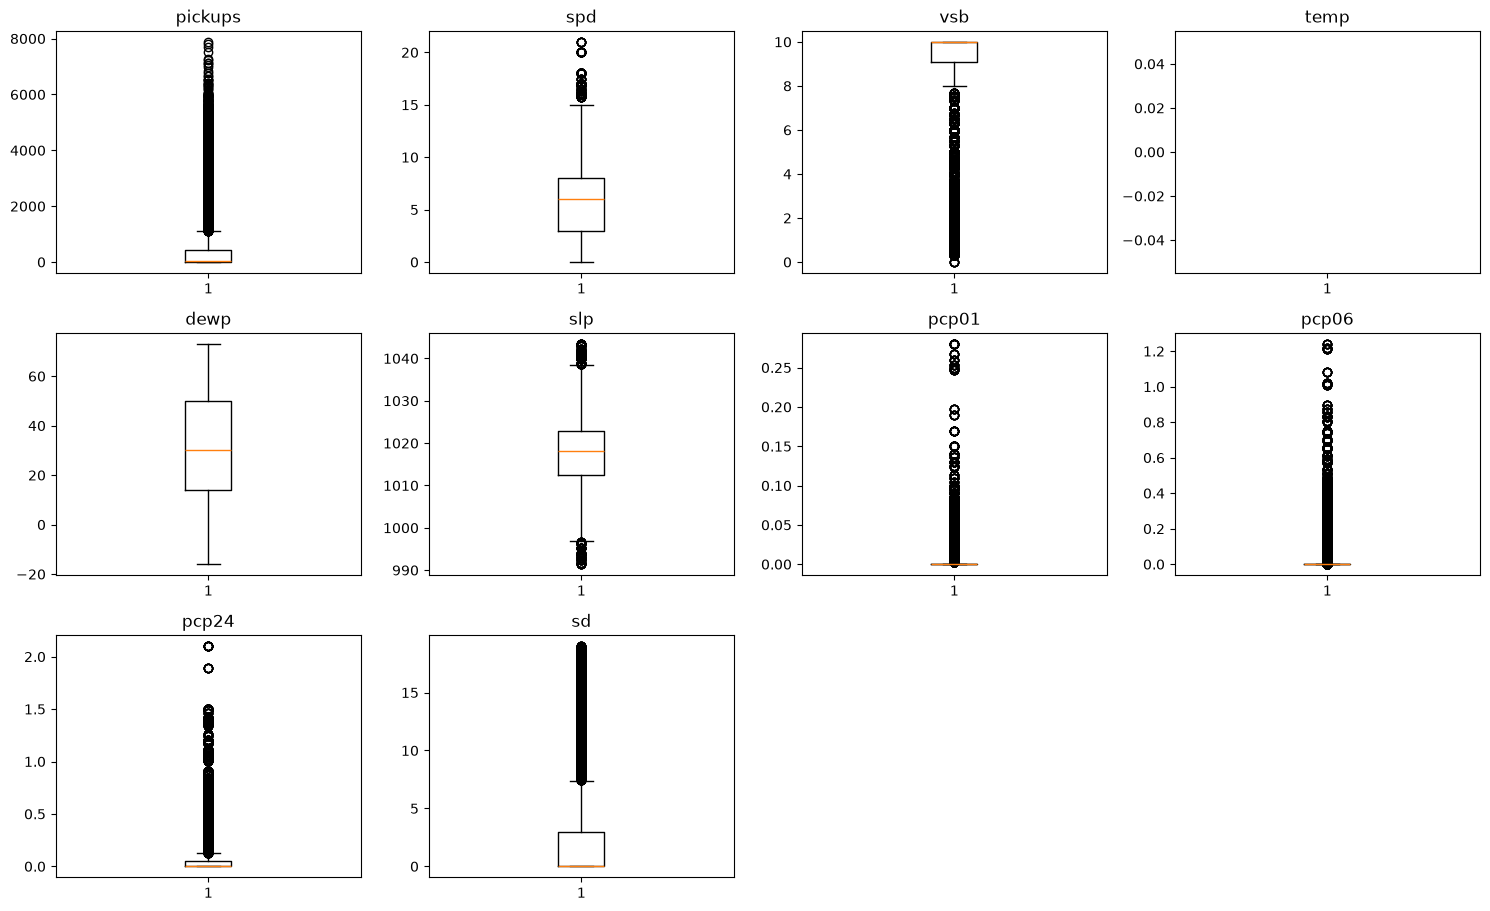

In [132]:
# outlier detection using boxplot
# selecting the numerical columns of data and adding their names in a list
numeric_columns = ['pickups','spd','vsb','temp','dewp', 'slp','pcp01', 'pcp06', 'pcp24', 'sd']
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- *The `pickups` column has a wide range of values with lots of outliers. However we are not going to treat this column since the number of pickups can have a varying range and we can miss out on some genuine values if we treat this column*
- *Starting from `spd` to `sd`, all the columns are related to weather. The weather related variables have some outliers, however all of them seem to be genuine values. So we are not going to treat the outliers present in these columns*

#### **Insights**

We analyzed a dataset of nearly 30K hourly Uber pickup informations, from New York boroughs.
The data spanned over every day of the first six months of the year 2015.
The main feature of interest here is the number of pickups.
Both from an environmental and business perspective, having cars roaming in an area while the demand is in another or filling the streets with cars during a low demand period while lacking during peak hours is inefficient. Thus we determined the factors that effect pickup and the nature of their effect.

We have been able to conclude that -  

1. Uber cabs are most popular in the Manhattan area of New York
2. Contrary to intuition, weather conditions do not have much impact on the number of Uber pickups
3. The demand for Uber has been increasing steadily over the months (Jan to June)
4. The rate of pickups is higher on the weekends as compared to weekdays
5. It is encouraging to see that New Yorkers trust Uber taxi services when they step out to enjoy their evenings
6. We can also conclude that people use Uber for regular office commutes.The demand steadily increases from 6 AM to 10 AM, then declines a little and starts picking up till midnight. The demand peaks at 7-8 PM
7. We need to further investigate the low demand for Uber on Mondays


#### **Recommendations to business**

1. Manhattan is the most mature market for Uber. Brooklyn, Queens, and Bronx show potential
2. There has been a gradual increase in Uber rides over the last few months and we need to keep up the momentum
3. The number of rides are high at peak office commute hours on weekdays and during late evenings on Saturdays. Cab availability must be ensured during these times
4. The demand for cabs is highest on Saturday nights. Cab availability must be ensured during this time of the week
5. Data should be procured for fleet size availability to get a better understanding of the demand-supply status and build a machine learning model to accurately predict pickups per hour, to optimize the cab fleet in respective areas
6. More data should be procured on price and a model can be built that can predict optimal pricing

####  **Further Analysis that can be done**

1. Dig deeper to explore the variation of cab demand, during working days and non-working days. You can combine Weekends+Holidays to be non-working days and weekdays to be the working days
2. Drop the boroughs that have negligible pickups and then analyze the data to uncover more insights